# ECMWF Open Data
The ECMWF provides a subset of its forecasting data as open data. The data can be downloaded anonimously without setting up an account. The [ecmwf.opendata](https://github.com/ecmwf/ecmwf-opendata) Python package provides the method to access and download the data. The forecast are available for only one step, e.g. at 12:00 for the same day of the request. The data format is GRIB. Xarray can read the data if the [cgrib engine](https://github.com/ecmwf/cfgrib) is installed. Links to more info are in the references. The ECMWF makes [plots and charts](https://charts.ecmwf.int/) from weather data using [Metview](https://metview.readthedocs.io/en/latest/), a software platform for the analysis of weather data. In this notebook we use Xarray and Matplotlib.

In [109]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
from ecmwf.opendata import Client
import pygrib

In [22]:
client = Client("ecmwf", beta=False)

To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


From the variables available we select the 2m temperature and the mean sea level pressure.

In [112]:
parameters = ['2t', 'msl']
filename = 'forecast-24-t2m-msl.grib'
filename

'forecast-24-t2m-msl.grib'

In [115]:
client.retrieve(
    date=0,
    time=0,
    step=12,
    stream="oper",
    type="fc",
    levtype="sfc",
    param=parameters,
    target=filename
)

20260526000000-12h-oper-fc.grib2:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

In [116]:
ds = xr.load_dataset(filename, engine="cfgrib")
ds

<xarray.Dataset> Size: 8MB
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] 8B 2026-05-26
    step               timedelta64[ns] 8B 12:00:00
    heightAboveGround  float64 8B 2.0
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time         datetime64[ns] 8B 2026-05-26T12:00:00
    meanSea            float64 8B 0.0
Data variables:
    t2m                (latitude, longitude) float32 4MB 264.5 264.5 ... 223.0
    msl                (latitude, longitude) float32 4MB 9.972e+04 ... 1.009e+05
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-26T16:38 GRIB to CDM+CF via cfgrib-0.9.1...

## 2m surface temperature

In [117]:
temperature2m = ds['t2m']

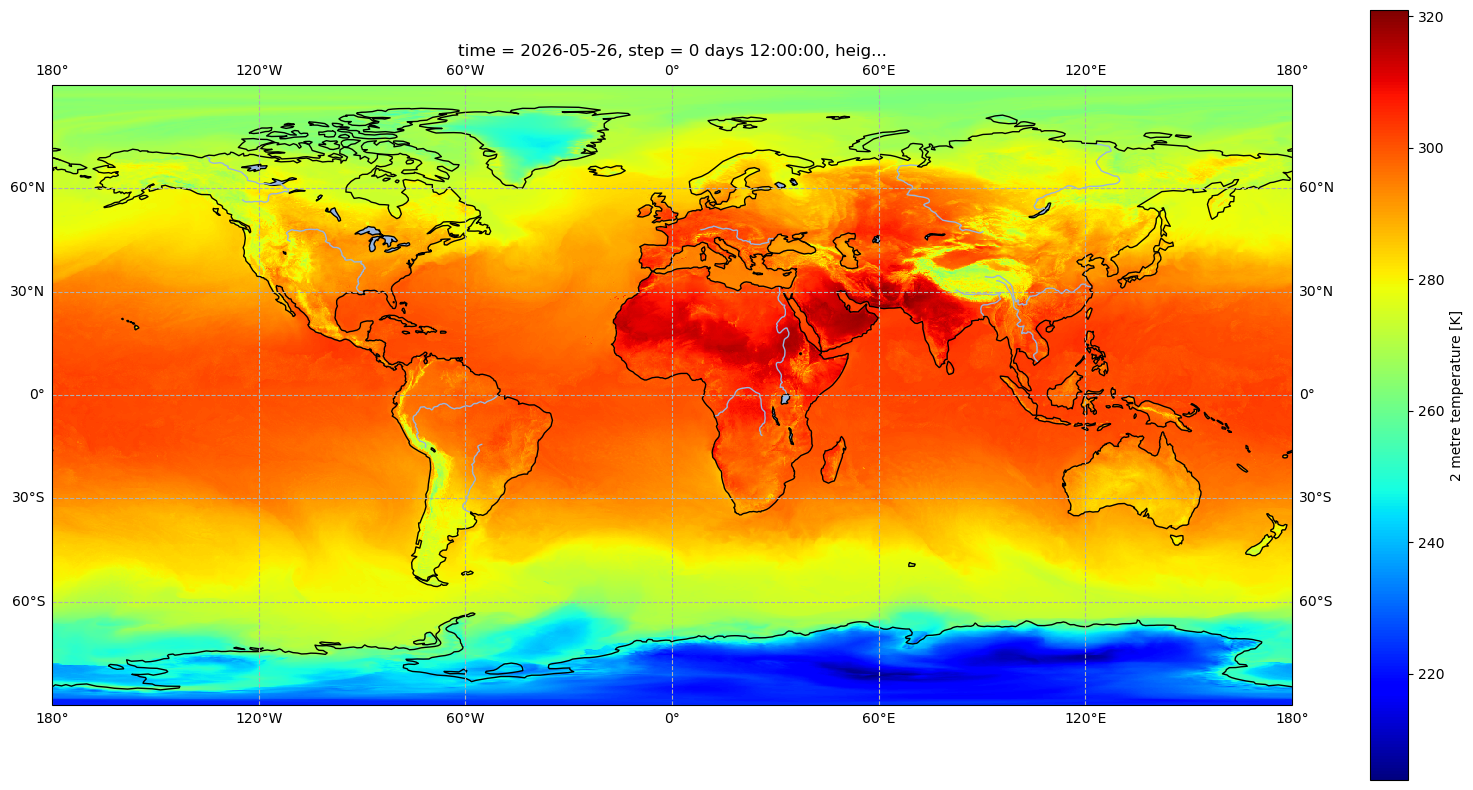

In [118]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linestyle='--')
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.LAND, edgecolor='black')
ax.add_feature(cartopy.feature.LAKES, edgecolor='black')
ax.add_feature(cartopy.feature.RIVERS)
ax.coastlines()
temperature2m.plot(ax=ax, add_colorbar=True, cmap='jet')

## Mean sea level pressure

mean_sea_level_pressure = ds['msl']

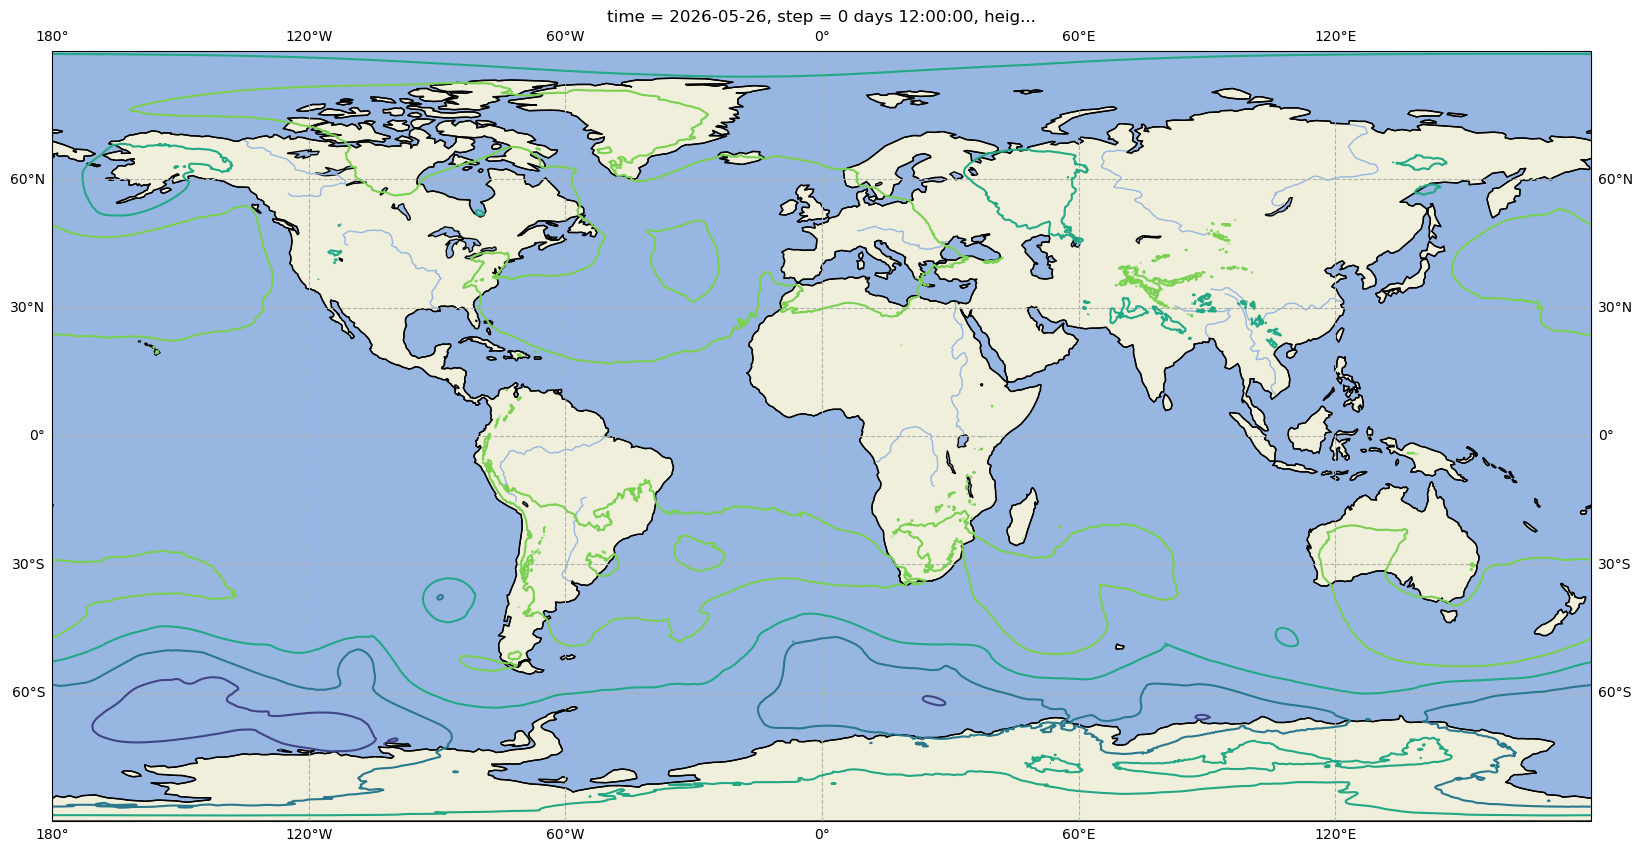

In [119]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linestyle='--')
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.LAND, edgecolor='black')
ax.add_feature(cartopy.feature.LAKES, edgecolor='black')
ax.add_feature(cartopy.feature.RIVERS)
ax.coastlines()
mean_sea_level_pressure.plot.contour(ax=ax, add_colorbar=False, add_labels=True)

## Selecting an area of interest
We can focus on a specific area by selecting a bounding box. 

In [120]:
bb_north = 60.0
bb_south = 35.0
bb_west = -10.0
bb_east = 40.0

In [121]:
aoi_2mtemp = temperature2m.sel(latitude = slice(bb_north, bb_south), 
                                 longitude = slice(bb_west, bb_east))

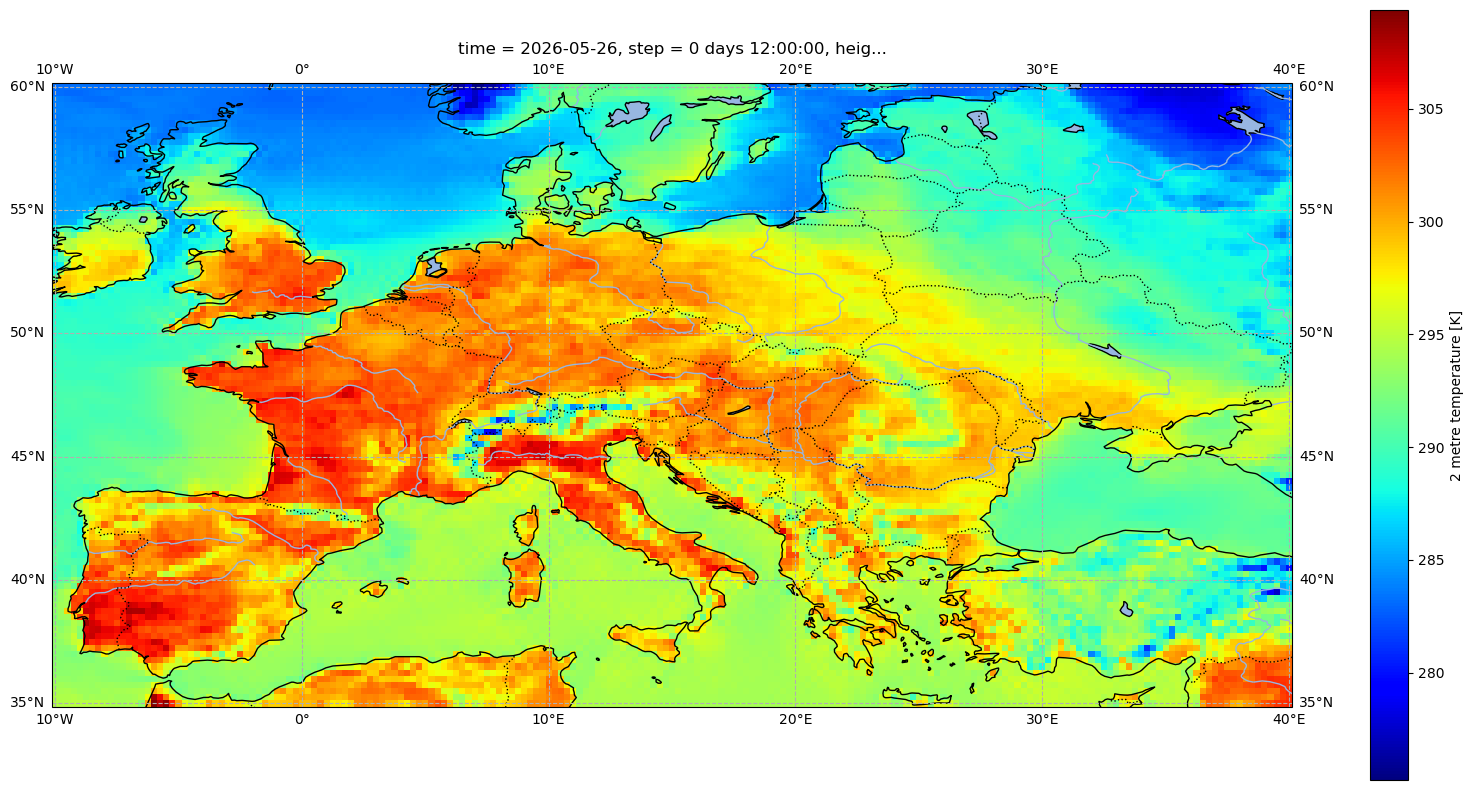

In [122]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linestyle='--')
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.LAND, edgecolor='black')
ax.add_feature(cartopy.feature.LAKES, edgecolor='black')
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.coastlines()
aoi_2mtemp.plot(ax=ax, add_colorbar=True, cmap='jet')

In [123]:
print('Max 2m temperature: {:.2f} °C'.format(aoi_2mtemp.max().values - 273.0))

Max 2m temperature: 36.39 °C


In [124]:
aoi_msl = mean_sea_level_pressure.sel(latitude = slice(bb_north, bb_south), 
                                 longitude = slice(bb_west, bb_east))

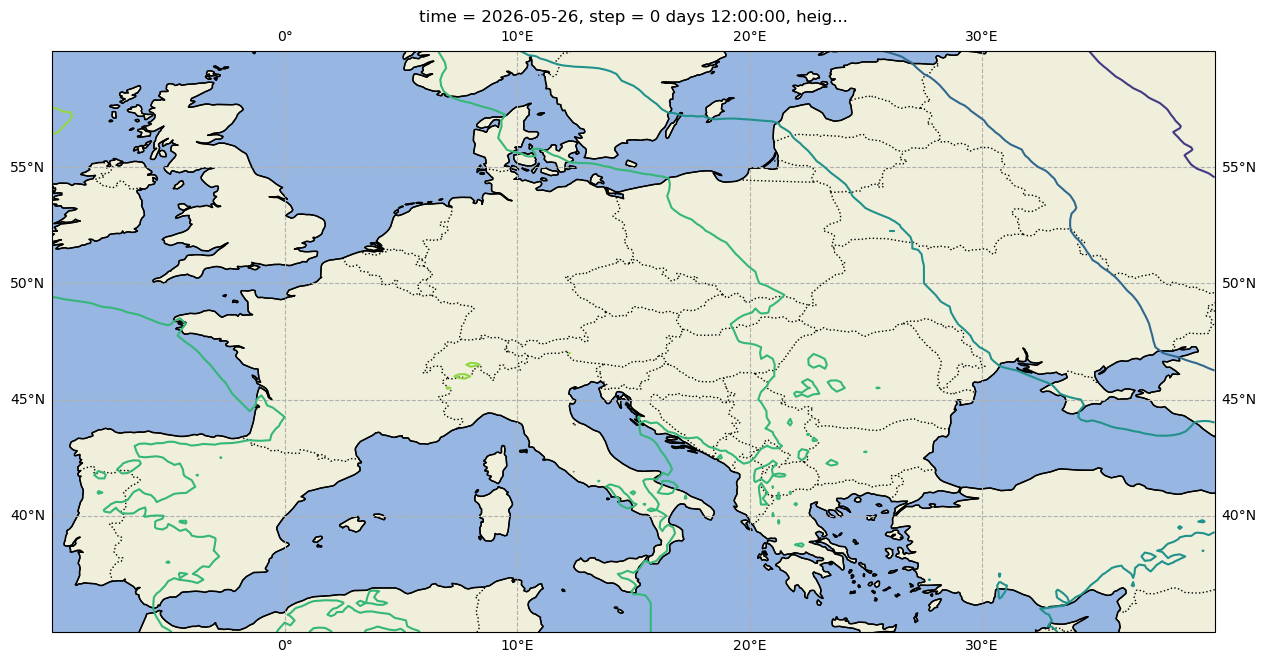

In [125]:
plt.figure(figsize=(15,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linestyle='--')
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.LAND, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.coastlines()
aoi_msl.plot.contour(ax=ax, add_colorbar=False)

## References
* [ECMWF Open Data](https://www.ecmwf.int/en/forecasts/datasets/open-data)